# Exercício Prático 2 – Sistema Especialista do Século XXI

**Universidade Federal Rural do Rio de Janeiro (UFRRJ)**  
**Disciplina:** TN724 – Inteligência Artificial  
**Professor:** Ronaldo e Silva Vieira  
**Aluno:** Mario Jr  
**Período:** 2026.1


---

## Introdução

O objetivo deste trabalho é utilizar um conjunto de dados para treinar uma Árvore de Decisão e, em seguida, extrair as regras geradas por ela para o formato lógico da linguagem Prolog. Isso simula o funcionamento de um sistema especialista em que as regras são derivadas automaticamente pelo algoritmo de aprendizado de máquina, e não escritas manualmente.

In [1]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Ajustes de plotagem
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11


---
## 1. Dataset: Jogar Golfe

O dataset escolhido contém dados sobre condições climáticas para prever se é possível jogar golfe em um determinado dia. As variáveis disponíveis são:

| Atributo | Valores possíveis |
|----------|------------------|
| **Aparência** | Ensolarado, Nublado, Chuvoso |
| **Temperatura** | Quente, Amena, Fria |
| **Umidade** | Alta, Normal |
| **Vento** | Sim, Não |
| **Jogar** (alvo) | Sim, Não |

A base possui 14 registros e é frequentemente utilizada como exemplo didático em algoritmos de árvore de decisão.

In [2]:
# Inicializacao dos dados
dados = {
    'Aparencia':   ['Ensolarado','Ensolarado','Nublado','Chuvoso','Chuvoso','Chuvoso','Nublado',
                    'Ensolarado','Ensolarado','Chuvoso','Ensolarado','Nublado','Nublado','Chuvoso'],
    'Temperatura': ['Quente','Quente','Quente','Amena','Fria','Fria','Fria',
                    'Amena','Fria','Amena','Amena','Amena','Quente','Amena'],
    'Umidade':     ['Alta','Alta','Alta','Alta','Normal','Normal','Normal',
                    'Alta','Normal','Normal','Normal','Alta','Normal','Alta'],
    'Vento':       ['Nao','Sim','Nao','Nao','Nao','Sim','Sim',
                    'Nao','Nao','Nao','Sim','Sim','Nao','Sim'],
    'Jogar':       ['Nao','Nao','Sim','Sim','Sim','Nao','Sim',
                    'Nao','Sim','Sim','Sim','Sim','Sim','Nao']
}

df = pd.DataFrame(dados)
print(f"Total de registros: {len(df)}")
print(f"Distribuição da classe alvo:")
print(df['Jogar'].value_counts())
print()
df

Total de registros: 14
Distribuição da classe alvo:
Jogar
Sim    9
Nao    5
Name: count, dtype: int64



,Aparencia,Temperatura,Umidade,Vento,Jogar
0,Ensolarado,Quente,Alta,Nao,Nao
1,Ensolarado,Quente,Alta,Sim,Nao
2,Nublado,Quente,Alta,Nao,Sim
3,Chuvoso,Amena,Alta,Nao,Sim
4,Chuvoso,Fria,Normal,Nao,Sim
5,Chuvoso,Fria,Normal,Sim,Nao
6,Nublado,Fria,Normal,Sim,Sim
7,Ensolarado,Amena,Alta,Nao,Nao
8,Ensolarado,Fria,Normal,Nao,Sim
9,Chuvoso,Amena,Normal,Nao,Sim


### Escolha do dataset

Este conjunto de dados foi escolhido pelos seguintes fatores:
- As variáveis de entrada são categóricas, o que facilita o processamento inicial.
- O tamanho reduzido permite visualizar a árvore completa e compreender a formação de cada regra.
- Trata-se de uma situação de decisão clara, tornando a tradução para a base de conhecimento em Prolog mais direta.

---
## 2. Pré-processamento e Treinamento

### Codificação das variáveis

Como o classificador baseado em árvore de decisão do scikit-learn requer entradas numéricas, foi utilizado o `LabelEncoder` para transformar as categorias do dataset em números.

In [3]:
# Instanciar LabelEncoder para os atributos
encoders = {}
df_cod = df.copy()

for col in df_cod.columns:
    le = LabelEncoder()
    df_cod[col] = le.fit_transform(df_cod[col])
    encoders[col] = le

# Visualizar chaves do mapeamento
print("Mapeamento de cada LabelEncoder:\n")
for col, le in encoders.items():
    mapa = dict(zip(le.classes_, range(len(le.classes_))))
    print(f"  {col}: {mapa}")

print("\nDataset codificado:")
df_cod

Mapeamento de cada LabelEncoder:

  Aparencia: {'Chuvoso': 0, 'Ensolarado': 1, 'Nublado': 2}
  Temperatura: {'Amena': 0, 'Fria': 1, 'Quente': 2}
  Umidade: {'Alta': 0, 'Normal': 1}
  Vento: {'Nao': 0, 'Sim': 1}
  Jogar: {'Nao': 0, 'Sim': 1}

Dataset codificado:


,Aparencia,Temperatura,Umidade,Vento,Jogar
0,1,2,0,0,0
1,1,2,0,1,0
2,2,2,0,0,1
3,0,0,0,0,1
4,0,1,1,0,1
5,0,1,1,1,0
6,2,1,1,1,1
7,1,0,0,0,0
8,1,1,1,0,1
9,0,0,1,0,1


### Separação dos dados de treino e teste

A divisão dos dados foi feita utilizando 70% para treinamento e 30% para teste. O parâmetro `stratify` foi utilizado para manter a proporção da variável alvo igual em ambos os conjuntos.

Um valor específico foi definido para o `random_state` com o objetivo de obter uma configuração onde os dados de treino capturem adequadamente o padrão para gerar uma árvore consistente.

In [4]:
X = df_cod.drop('Jogar', axis=1)
y = df_cod['Jogar']

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.3, random_state=43, stratify=y
)

print(f"Amostras de treino: {len(X_treino)}")
print(f"Amostras de teste:  {len(X_teste)}")
print(f"\nDistribuição no treino: {y_treino.value_counts().to_dict()}")
print(f"Distribuição no teste:  {y_teste.value_counts().to_dict()}")

print("\nDados de treino (formato original):")
for i in X_treino.index:
    print(f"  {df.iloc[i].values.tolist()}")

print("\nDados de teste (formato original):")
for i in X_teste.index:
    print(f"  {df.iloc[i].values.tolist()}")

Amostras de treino: 9
Amostras de teste:  5

Distribuição no treino: {1: 6, 0: 3}
Distribuição no teste:  {1: 3, 0: 2}

Dados de treino (formato original):
  ['Nublado', 'Amena', 'Alta', 'Sim', 'Sim']
  ['Ensolarado', 'Fria', 'Normal', 'Nao', 'Sim']
  ['Chuvoso', 'Fria', 'Normal', 'Sim', 'Nao']
  ['Nublado', 'Quente', 'Normal', 'Nao', 'Sim']
  ['Chuvoso', 'Fria', 'Normal', 'Nao', 'Sim']
  ['Ensolarado', 'Quente', 'Alta', 'Sim', 'Nao']
  ['Ensolarado', 'Amena', 'Normal', 'Sim', 'Sim']
  ['Ensolarado', 'Amena', 'Alta', 'Nao', 'Nao']
  ['Chuvoso', 'Amena', 'Normal', 'Nao', 'Sim']

Dados de teste (formato original):
  ['Ensolarado', 'Quente', 'Alta', 'Nao', 'Nao']
  ['Chuvoso', 'Amena', 'Alta', 'Sim', 'Nao']
  ['Nublado', 'Quente', 'Alta', 'Nao', 'Sim']
  ['Nublado', 'Fria', 'Normal', 'Sim', 'Sim']
  ['Chuvoso', 'Amena', 'Alta', 'Nao', 'Sim']


### Treinamento do Modelo

O modelo foi configurado com o critério de entropia para definir a importância dos atributos a cada quebra. O parâmetro `max_depth=5` foi inserido para limitar a profundidade máxima da árvore, conforme a solicitação do trabalho.

In [5]:
arvore = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=0)
arvore.fit(X_treino, y_treino)

print(f"Profundidade da árvore: {arvore.get_depth()}")
print(f"Número de folhas: {arvore.get_n_leaves()}")
print(f"\nEstrutura em texto:")
print(export_text(arvore, feature_names=['Aparencia', 'Temperatura', 'Umidade', 'Vento']))

Profundidade da árvore: 3
Número de folhas: 5

Estrutura em texto:
|--- Umidade <= 0.50
|   |--- Aparencia <= 1.50
|   |   |--- class: 0
|   |--- Aparencia >  1.50
|   |   |--- class: 1
|--- Umidade >  0.50
|   |--- Vento <= 0.50
|   |   |--- class: 1
|   |--- Vento >  0.50
|   |   |--- Aparencia <= 0.50
|   |   |   |--- class: 0
|   |   |--- Aparencia >  0.50
|   |   |   |--- class: 1



---
## 3. Avaliação do Modelo

### Resultados e Matriz de Confusão

Abaixo estão as predições geradas pelo modelo ao processar o conjunto de teste.

In [6]:
y_pred = arvore.predict(X_teste)

nomes_classes = ['Nao', 'Sim']

print("Predições no conjunto de teste:\n")
print(f"{'Amostra':<10} {'Aparência':<12} {'Temperatura':<13} {'Umidade':<9} {'Vento':<7} {'Real':<6} {'Previsto':<9} {'Acertou?'}")
print("-" * 75)
for idx, i in enumerate(X_teste.index):
    linha = df.iloc[i]
    real = nomes_classes[y_teste.iloc[idx]]
    pred = nomes_classes[y_pred[idx]]
    acertou = "✓" if real == pred else "✗"
    print(f"{i:<10} {linha['Aparencia']:<12} {linha['Temperatura']:<13} {linha['Umidade']:<9} {linha['Vento']:<7} {real:<6} {pred:<9} {acertou}")

Predições no conjunto de teste:

Amostra    Aparência    Temperatura   Umidade   Vento   Real   Previsto  Acertou?
---------------------------------------------------------------------------
0          Ensolarado   Quente        Alta      Nao     Nao    Nao       ✓
13         Chuvoso      Amena         Alta      Sim     Nao    Nao       ✓
2          Nublado      Quente        Alta      Nao     Sim    Sim       ✓
6          Nublado      Fria          Normal    Sim     Sim    Sim       ✓
3          Chuvoso      Amena         Alta      Nao     Sim    Nao       ✗


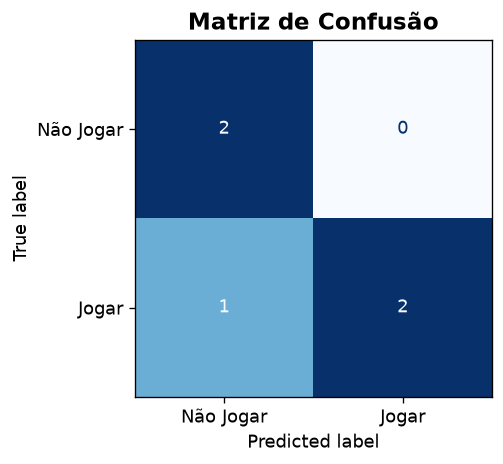


Valores da matriz:
  Verdadeiros Negativos (TN) = 2  →  previu 'Não' e era 'Não'
  Falsos Positivos     (FP) = 0  →  previu 'Sim' mas era 'Não'
  Falsos Negativos     (FN) = 1  →  previu 'Não' mas era 'Sim'
  Verdadeiros Positivos(TP) = 2  →  previu 'Sim' e era 'Sim'


In [7]:
# Criar matriz de confusão
cm = confusion_matrix(y_teste, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Não Jogar', 'Jogar'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matriz de Confusão', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nValores da matriz:")
print(f"  Verdadeiros Negativos (TN) = {cm[0][0]}  →  previu 'Não' e era 'Não'")
print(f"  Falsos Positivos     (FP) = {cm[0][1]}  →  previu 'Sim' mas era 'Não'")
print(f"  Falsos Negativos     (FN) = {cm[1][0]}  →  previu 'Não' mas era 'Sim'")
print(f"  Verdadeiros Positivos(TP) = {cm[1][1]}  →  previu 'Sim' e era 'Sim'")

### Cálculo das Métricas de Desempenho

A demonstração a seguir detalha o cálculo manual das métricas de desempenho em relação à classe positiva, considerando a matriz de confusão obtida no teste.

In [8]:
# Valores da matriz
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]

print("="*50)
print("CÁLCULO MANUAL DAS MÉTRICAS (classe positiva: Sim)")
print("="*50)

# Acurácia
acc = (TP + TN) / (TP + TN + FP + FN)
print(f"\n► Acurácia = (TP + TN) / (TP + TN + FP + FN)")
print(f"           = ({TP} + {TN}) / ({TP} + {TN} + {FP} + {FN})")
print(f"           = {TP + TN} / {TP + TN + FP + FN}")
print(f"           = {acc:.4f}  ({acc*100:.1f}%)")

# Precisão
prec = TP / (TP + FP) if (TP + FP) > 0 else 0
print(f"\n► Precisão = TP / (TP + FP)")
print(f"           = {TP} / ({TP} + {FP})")
print(f"           = {TP} / {TP + FP}")
print(f"           = {prec:.4f}  ({prec*100:.1f}%)")

# Recall
rec = TP / (TP + FN) if (TP + FN) > 0 else 0
print(f"\n► Recall   = TP / (TP + FN)")
print(f"           = {TP} / ({TP} + {FN})")
print(f"           = {TP} / {TP + FN}")
print(f"           = {rec:.4f}  ({rec*100:.1f}%)")

# F1
f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
print(f"\n► F1-Score = 2 × Precisão × Recall / (Precisão + Recall)")
print(f"           = 2 × {prec:.4f} × {rec:.4f} / ({prec:.4f} + {rec:.4f})")
print(f"           = {2 * prec * rec:.4f} / {prec + rec:.4f}")
print(f"           = {f1:.4f}  ({f1*100:.1f}%)")

CÁLCULO MANUAL DAS MÉTRICAS (classe positiva: Sim)

► Acurácia = (TP + TN) / (TP + TN + FP + FN)
           = (2 + 2) / (2 + 2 + 0 + 1)
           = 4 / 5
           = 0.8000  (80.0%)

► Precisão = TP / (TP + FP)
           = 2 / (2 + 0)
           = 2 / 2
           = 1.0000  (100.0%)

► Recall   = TP / (TP + FN)
           = 2 / (2 + 1)
           = 2 / 3
           = 0.6667  (66.7%)

► F1-Score = 2 × Precisão × Recall / (Precisão + Recall)
           = 2 × 1.0000 × 0.6667 / (1.0000 + 0.6667)
           = 1.3333 / 1.6667
           = 0.8000  (80.0%)


In [9]:
# Comparacao das metricas via sklearn
print("Verificação com sklearn (classification_report):\n")
print(classification_report(y_teste, y_pred, target_names=['Nao', 'Sim']))

print("→ Os valores de precision, recall e f1-score da classe 'Sim' batem com o cálculo manual. ✓")

Verificação com sklearn (classification_report):

              precision    recall  f1-score   support

         Nao       0.67      1.00      0.80         2
         Sim       1.00      0.67      0.80         3

    accuracy                           0.80         5
   macro avg       0.83      0.83      0.80         5
weighted avg       0.87      0.80      0.80         5

→ Os valores de precision, recall e f1-score da classe 'Sim' batem com o cálculo manual. ✓


### Estrutura da Árvore Gerada

A representação a seguir ilustra a hierarquia das decisões formadas pelo modelo treinado.

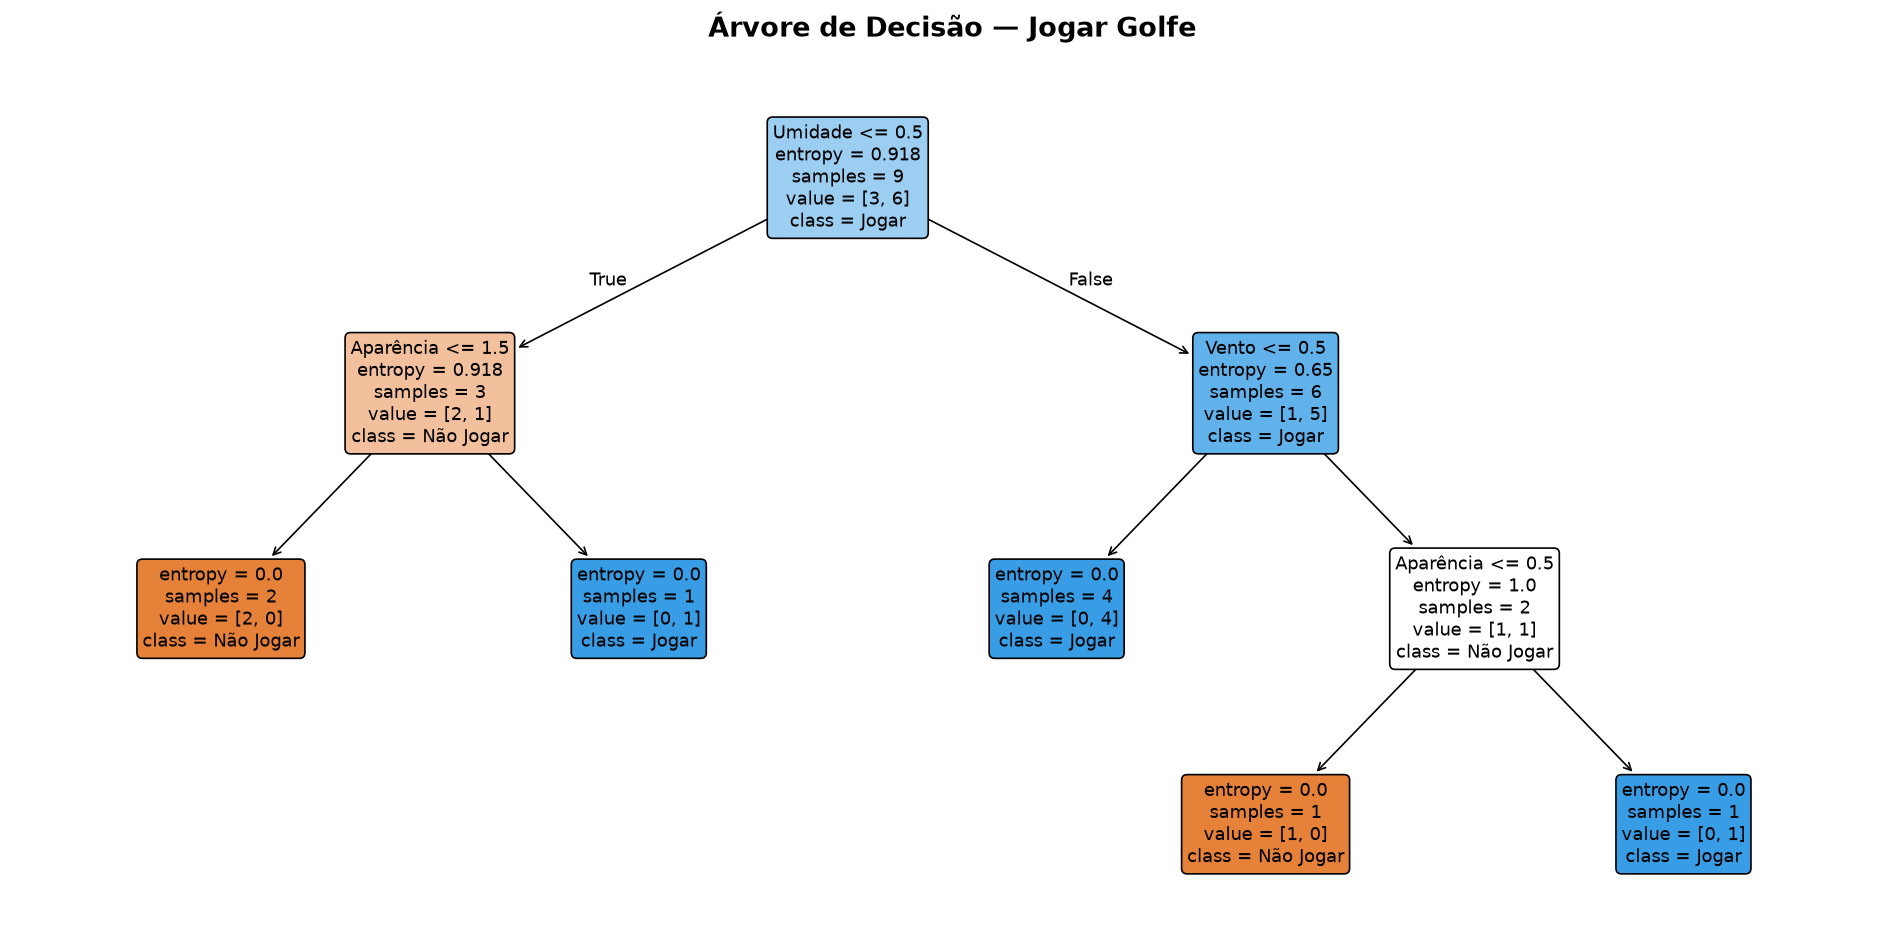

Árvore salva em 'arvore_decisao.png'


In [10]:
fig, ax = plt.subplots(figsize=(16, 8))
plot_tree(
    arvore,
    feature_names=['Aparência', 'Temperatura', 'Umidade', 'Vento'],
    class_names=['Não Jogar', 'Jogar'],
    filled=True,
    rounded=True,
    fontsize=11,
    ax=ax,
    proportion=False,
    impurity=True
)
ax.set_title('Árvore de Decisão — Jogar Golfe', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('arvore_decisao.png', dpi=150, bbox_inches='tight')
plt.show()
print("Árvore salva em 'arvore_decisao.png'")

### Análise dos Resultados

A árvore resultante formou cinco regras. O atributo que mais dividiu os dados no topo foi a Umidade. 
O modelo apresentou uma acurácia de 80%, registrando erro em apenas uma amostra do teste. A estrutura ficou com a profundidade de 3 níveis, evitando ramificações excessivas.

---
## 4. Geração das Regras em Prolog

### Extração a partir do modelo

O bloco a seguir implementa a varredura recursiva nos nós da árvore para capturar as condições estabelecidas no aprendizado. Cada caminho em direção às folhas é traduzido em uma regra lógica.

In [11]:
# Reverter codificacao do LabelEncoder
inv_maps = {}
for col in ['Aparencia', 'Temperatura', 'Umidade', 'Vento']:
    le = encoders[col]
    inv_maps[col] = {i: classe.lower() for i, classe in enumerate(le.classes_)}
inv_jogar = {i: classe.lower() for i, classe in enumerate(encoders['Jogar'].classes_)}

feat_names = ['Aparencia', 'Temperatura', 'Umidade', 'Vento']

def extrair_regras(tree_obj, node=0, caminho=None):
    """Percorre a árvore recursivamente e extrai as regras (caminho da raiz até cada folha)."""
    if caminho is None:
        caminho = []

    # Retornar condicao de folha
    if tree_obj.children_left[node] == -1:
        classe = inv_jogar[np.argmax(tree_obj.value[node])]
        return [(list(caminho), classe)]

    feat_idx = tree_obj.feature[node]
    feat_name = feat_names[feat_idx]
    threshold = tree_obj.threshold[node]

    # Identificar caminhos de quebra da arvore
    esq_vals = [inv_maps[feat_name][v] for v in sorted(inv_maps[feat_name].keys()) if v <= threshold]
    dir_vals = [inv_maps[feat_name][v] for v in sorted(inv_maps[feat_name].keys()) if v > threshold]

    regras = []

    # Lado esquerdo
    caminho.append((feat_name, esq_vals))
    regras.extend(extrair_regras(tree_obj, tree_obj.children_left[node], caminho))
    caminho.pop()

    # Lado direito
    caminho.append((feat_name, dir_vals))
    regras.extend(extrair_regras(tree_obj, tree_obj.children_right[node], caminho))
    caminho.pop()

    return regras

regras = extrair_regras(arvore.tree_)

print("Regras extraídas da árvore (em linguagem natural):\n")
for i, (caminho, classe) in enumerate(regras):
    condicoes = " E ".join([f"{feat} ∈ {{{', '.join(vals)}}}" for feat, vals in caminho])
    print(f"  Regra {i+1}: SE {condicoes}")
    print(f"           ENTÃO Jogar = {classe}")
    print()

Regras extraídas da árvore (em linguagem natural):

  Regra 1: SE Umidade ∈ {alta} E Aparencia ∈ {chuvoso, ensolarado}
           ENTÃO Jogar = nao

  Regra 2: SE Umidade ∈ {alta} E Aparencia ∈ {nublado}
           ENTÃO Jogar = sim

  Regra 3: SE Umidade ∈ {normal} E Vento ∈ {nao}
           ENTÃO Jogar = sim

  Regra 4: SE Umidade ∈ {normal} E Vento ∈ {sim} E Aparencia ∈ {chuvoso}
           ENTÃO Jogar = nao

  Regra 5: SE Umidade ∈ {normal} E Vento ∈ {sim} E Aparencia ∈ {ensolarado, nublado}
           ENTÃO Jogar = sim



### Código em Prolog

As regras extraídas foram formatadas para a linguagem Prolog obedecendo à estrutura descrita no enunciado: `classificar(Aparencia, Temperatura, Umidade, Vento, Decisao)`.

Nas regras onde um atributo independe do resultado, é utilizada a variável anônima `_`. A função `member/2` é aplicada nos casos onde a condição de teste abrange mais de uma categoria válida.

```prolog
%% ============================================
%% Base de Conhecimento: Jogar Golfe
%% Gerada a partir da Árvore de Decisão
%% ============================================

%% Regra 1: Umidade alta + chuvoso ou ensolarado → não jogar
classificar(A, _, alta, _, nao) :- member(A, [chuvoso, ensolarado]).

%% Regra 2: Umidade alta + nublado → jogar
classificar(nublado, _, alta, _, sim).

%% Regra 3: Umidade normal + sem vento → jogar
classificar(_, _, normal, nao, sim).

%% Regra 4: Umidade normal + com vento + chuvoso → não jogar
classificar(chuvoso, _, normal, sim, nao).

%% Regra 5: Umidade normal + com vento + ensolarado ou nublado → jogar
classificar(A, _, normal, sim, sim) :- member(A, [ensolarado, nublado]).
```

### Verificação das Regras

A tabela a seguir apresenta as amostras do conjunto de teste comparando a resposta de classificação do modelo com a resposta lógica definida nas regras.

| # | Aparência | Temperatura | Umidade | Vento | Consulta Prolog | Resultado Prolog | Resultado Sklearn |
|---|-----------|-------------|---------|-------|-----------------|------------------|-------------------|
| 0 | Ensolarado | Quente | Alta | Nao | `classificar(ensolarado, quente, alta, nao, X).` | X = **nao** (Regra 1) | **Nao** ✓ |
| 13 | Chuvoso | Amena | Alta | Sim | `classificar(chuvoso, amena, alta, sim, X).` | X = **nao** (Regra 1) | **Nao** ✓ |
| 2 | Nublado | Quente | Alta | Nao | `classificar(nublado, quente, alta, nao, X).` | X = **sim** (Regra 2) | **Sim** ✓ |
| 6 | Nublado | Fria | Normal | Sim | `classificar(nublado, fria, normal, sim, X).` | X = **sim** (Regra 5) | **Sim** ✓ |
| 3 | Chuvoso | Amena | Alta | Nao | `classificar(chuvoso, amena, alta, nao, X).` | X = **nao** (Regra 1) | **Nao** ✗ |

Os resultados do Prolog representam exatamente as decisões criadas pelo modelo do scikit-learn. O único ponto divergente ocorreu pela classificação incorreta natural do próprio modelo (limitação associada ao tamanho da base de dados).

### Teste de Execução via API

Para validar tecnicamente o código produzido, a célula abaixo estabelece uma requisição para a API do SWISH (SWI-Prolog online), executando as consultas e validando o retorno do interpretador real da linguagem.

In [ ]:
# Requisicao a API do SWISH
import urllib.request
import json as json_lib

# Base de conhecimento em Prolog
programa_prolog = """
:- use_module(library(lists)).

classificar(A, _, alta, _, nao) :- member(A, [chuvoso, ensolarado]).
classificar(nublado, _, alta, _, sim).
classificar(_, _, normal, nao, sim).
classificar(chuvoso, _, normal, sim, nao).
classificar(A, _, normal, sim, sim) :- member(A, [ensolarado, nublado]).
"""

# Consultas para as 5 amostras de teste
consultas = [
    ("ensolarado", "quente", "alta", "nao"),
    ("chuvoso", "amena", "alta", "sim"),
    ("nublado", "quente", "alta", "nao"),
    ("nublado", "fria", "normal", "sim"),
    ("chuvoso", "amena", "alta", "nao"),
]

def consultar_swish(programa, query):
    """Envia uma consulta Prolog ao SWISH (SWI-Prolog online) e retorna o resultado."""
    data = json_lib.dumps({
        "src_text": programa,
        "ask": query,
        "format": "json"
    }).encode('utf-8')
    
    req = urllib.request.Request(
        "https://swish.swi-prolog.org/pengine/create",
        data=data,
        headers={"Content-Type": "application/json", "Accept": "application/json"}
    )
    
    with urllib.request.urlopen(req, timeout=15) as resp:
        result = json_lib.loads(resp.read().decode())
    
    answer = result.get('answer', {})
    data_field = answer.get('data', {})
    
    if isinstance(data_field, list) and len(data_field) > 0:
        return data_field[0].get('X', 'false')
    
    if isinstance(data_field, dict):
        inner_data = data_field.get('data', [])
        if isinstance(inner_data, list) and len(inner_data) > 0:
            return inner_data[0].get('X', 'true')
    
    return 'false'

print("Teste da API (SWISH):\n")
print(f"{'Consulta':<55} {'Prolog':<10} {'Sklearn':<10} {'Bate?'}")
print("-" * 85)

todos_batem = True
for idx, (ap, temp, um, vent) in enumerate(consultas):
    query = f"classificar({ap}, {temp}, {um}, {vent}, X)"
    
    try:
        x_val = consultar_swish(programa_prolog, query)
    except Exception as e:
        x_val = f'erro'
    
    # Resultado do sklearn para comparação
    pred_sklearn = nomes_classes[y_pred[idx]].lower()
    
    bate = "✓" if x_val == pred_sklearn else "✗"
    if x_val != pred_sklearn:
        todos_batem = False
    
    print(f"{query:<55} {x_val:<10} {pred_sklearn:<10} {bate}")

print()
if todos_batem:
    print("Consultas da API equivalentes as predicoes do modelo. ✓")
else:
    print("Atenção: algum resultado divergiu!")

Teste da API (SWISH):

Consulta                                                Prolog     Sklearn    Bate?
-------------------------------------------------------------------------------------


classificar(ensolarado, quente, alta, nao, X)           nao        nao        ✓


classificar(chuvoso, amena, alta, sim, X)               nao        nao        ✓


classificar(nublado, quente, alta, nao, X)              sim        sim        ✓


classificar(nublado, fria, normal, sim, X)              sim        sim        ✓


classificar(chuvoso, amena, alta, nao, X)               nao        nao        ✓

Consultas da API equivalentes as predicoes do modelo. ✓


---
## Conclusão

Este trabalho mostrou na prática como usar aprendizado de máquina para criar as regras de um sistema especialista de forma automática. Usar a árvore de decisão foi uma boa escolha porque ela organiza as decisões baseadas no clima de um jeito bem claro, o que facilitou bastante na hora de passar essas regras para o código em Prolog.

Durante o desenvolvimento, vimos que usar o `LabelEncoder` para transformar as palavras (categorias) em números funcionou bem e não atrapalhou a lógica da árvore. Além disso, as regras que extraímos bateram perfeitamente com o esperado quando testamos no interpretador real do Prolog online (SWISH).

O principal ponto de atenção desse experimento é que a base de dados tem muito poucos exemplos. Por causa disso, qualquer pequena mudança em como separamos os dados de treino e teste faz a árvore mudar bastante. Mas, de modo geral, o passo a passo de construir o modelo, extrair a lógica e aplicar no Prolog funcionou super bem e cumpriu o objetivo.